# Open-hole petrophysics: from log curves to decisions

*Part 3 of the book plus the `fwap` extension layer — dispersion, elastic
moduli, fluid substitution, Stoneley permeability, and a drilling-decision
mud-weight window.*

The [processing tutorial](open_hole_processing.ipynb) ended with slowness logs.
Slowness is not the deliverable, though: a petrophysicist wants moduli, a
reservoir engineer wants permeability, and a drilling engineer wants to know
what mud weight will keep the hole open. This notebook walks that second half.

1. **Dispersion** — why a dipole shear pick needs a correction the P pick does not.
2. **Elastic moduli** and **Gassmann fluid substitution**.
3. **Stoneley permeability** — the tube wave as a fluid-mobility probe.
4. **Geomechanics** — brittleness, closure stress, and a safe mud-weight window.

## Setup

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import fwap
from fwap import (
    dipole_flexural_dispersion,
    elastic_moduli,
    flexural_dispersion,
    gassmann_fluid_substitution,
    geomechanics_indices,
    hydrostatic_pressure,
    overburden_stress,
    safe_mud_weight_window,
    stoneley_dispersion,
    stoneley_permeability_tang_cheng,
    unconfined_compressive_strength,
)

US_PER_FT = 1.0e6 * 0.3048
print("fwap", fwap.__version__)

fwap 0.4.0


## 1. Dispersion: the dipole shear needs a correction

A monopole P head wave is non-dispersive — its slowness is the formation's, full
stop. The dipole **flexural** mode is not: it travels at the formation shear
speed only in the low-frequency limit and slows down as frequency rises. Pick it
at the wrong frequency and the shear log is biased slow.

`fwap` provides both a fast phenomenological law and the real cylindrical-Biot
modal solver. Below, the solver's Stoneley and flexural curves for one
formation.

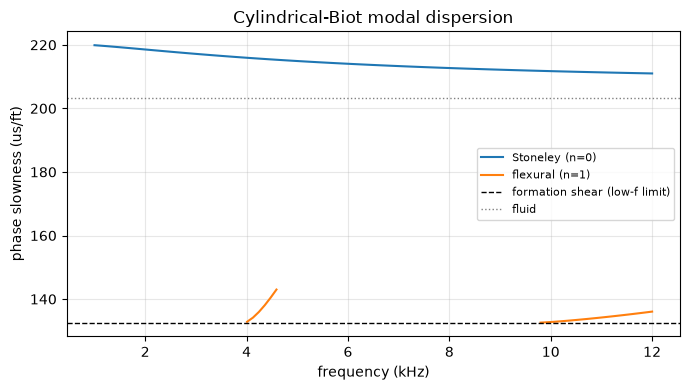

flexural slowness at 12.0 kHz is +3.5 us/ft off the true shear slowness
-> picking the flexural mode high in the band biases DTS SLOW; this is the
   bias `dispersive_stc` removes by searching over a dispersion family.


In [2]:
freq = np.linspace(1000.0, 12000.0, 96)
formation = dict(vp=4000.0, vs=2300.0, rho=2400.0, vf=1500.0, rho_f=1000.0, a=0.1)

st = stoneley_dispersion(freq, **formation)
fl = flexural_dispersion(freq, **formation)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(freq / 1e3, st.slowness * US_PER_FT, label="Stoneley (n=0)")
ax.plot(freq / 1e3, fl.slowness * US_PER_FT, label="flexural (n=1)")
ax.axhline(US_PER_FT / formation["vs"], color="k", ls="--", lw=1,
           label="formation shear (low-f limit)")
ax.axhline(US_PER_FT / formation["vf"], color="grey", ls=":", lw=1, label="fluid")
ax.set_xlabel("frequency (kHz)")
ax.set_ylabel("phase slowness (us/ft)")
ax.set_title("Cylindrical-Biot modal dispersion")
ax.grid(alpha=0.3)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

finite = np.isfinite(fl.slowness)
bias = (fl.slowness[finite][-1] - 1.0 / formation["vs"]) * US_PER_FT
print(f"flexural slowness at {freq[finite][-1]/1e3:.1f} kHz is "
      f"{bias:+.1f} us/ft off the true shear slowness")
print("-> picking the flexural mode high in the band biases DTS SLOW; this is the")
print("   bias `dispersive_stc` removes by searching over a dispersion family.")

## 2. Elastic moduli and fluid substitution

With Vp, Vs and density, the isotropic moduli follow directly. Gassmann then
answers the reservoir question: *what would these logs look like if the pore
fluid were different?*

In [3]:
vp, vs, rho = 4000.0, 2300.0, 2400.0
m = elastic_moduli(vp=np.array([vp]), vs=np.array([vs]), rho=np.array([rho]))
print(f"K   = {float(m.k[0]) / 1e9:6.2f} GPa")
print(f"mu  = {float(m.mu[0]) / 1e9:6.2f} GPa")
print(f"E   = {float(m.young[0]) / 1e9:6.2f} GPa")
print(f"nu  = {float(m.poisson[0]):6.3f}")

# Brine -> gas substitution in a 20% porosity sandstone.
porosity = np.array([0.20])
res = gassmann_fluid_substitution(
    k_dry=m.k * 0.75,   # dry frame, softer than saturated
    mu_dry=m.mu,                              # shear modulus is fluid-insensitive
    k_mineral=np.array([37.0e9]),             # quartz
    k_fluid=np.array([0.04e9]),               # gas
    porosity=porosity,
)
print(f"\nbrine-saturated K = {float(m.k[0]) / 1e9:5.2f} GPa")
print(f"gas-substituted  K = {float(res.k_sat[0]) / 1e9:5.2f} GPa")
print("mu unchanged by fluid:", np.isclose(res.mu_sat[0], m.mu[0]))

K   =  21.47 GPa
mu  =  12.70 GPa
E   =  31.82 GPa
nu  =  0.253

brine-saturated K = 21.47 GPa
gas-substituted  K = 16.17 GPa
mu unchanged by fluid: True


## 3. Stoneley permeability

The Stoneley tube wave pushes fluid in and out of the formation as it passes. In
a permeable interval that costs energy, so the wave slows and attenuates. The
Tang–Cheng–Toksöz inversion turns that slowdown into a permeability estimate.

We sweep a synthetic slowdown here to show the response shape — a real log feeds
the measured `DTST` curve in against an impermeable reference.

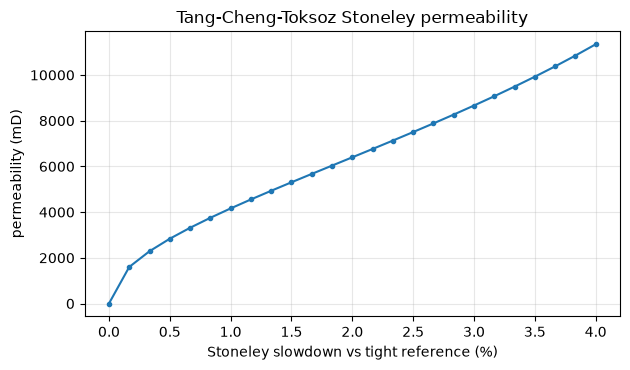

a 2% Stoneley slowdown maps to ~6398 mD


In [4]:
reference = 1.0 / 1400.0                       # tight (impermeable) baseline
excess = np.linspace(0.0, 0.04, 25)            # fractional Stoneley slowdown
observed = reference * (1.0 + excess)

perm = stoneley_permeability_tang_cheng(
    slowness_observed=observed,
    slowness_reference=reference,
    frequency=3000.0,
    fluid_bulk_modulus=2.25e9,
    fluid_viscosity=1.0e-3,
    fluid_density=1000.0,
    porosity=np.full_like(observed, 0.20),
    frame_bulk_modulus=np.full_like(observed, 15.0e9),
)

fig, ax = plt.subplots(figsize=(6.4, 3.8))
ax.plot(excess * 100.0, perm * 1e15, "-o", ms=3)
ax.set_xlabel("Stoneley slowdown vs tight reference (%)")
ax.set_ylabel("permeability (mD)")
ax.set_title("Tang-Cheng-Toksoz Stoneley permeability")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print(f"a 2% Stoneley slowdown maps to ~{np.interp(0.02, excess, perm) * 1e15:.0f} mD")

## 4. Geomechanics: a safe mud-weight window

The drilling deliverable. Integrate density for overburden, estimate pore
pressure, get rock strength from the moduli, and solve for the mud-weight band
that is heavy enough to hold the wall against shear breakout but light enough
not to fracture it.

One trap to walk into deliberately: the Lacy UCS correlation was fitted on
**static** Young's moduli from core, but a sonic log gives the **dynamic**
modulus, which is larger by roughly 1.5–3x in porous rock. Feeding the dynamic
value in straight returns an upper bound — often implausibly high. We print both
so the size of that gap is visible rather than buried.

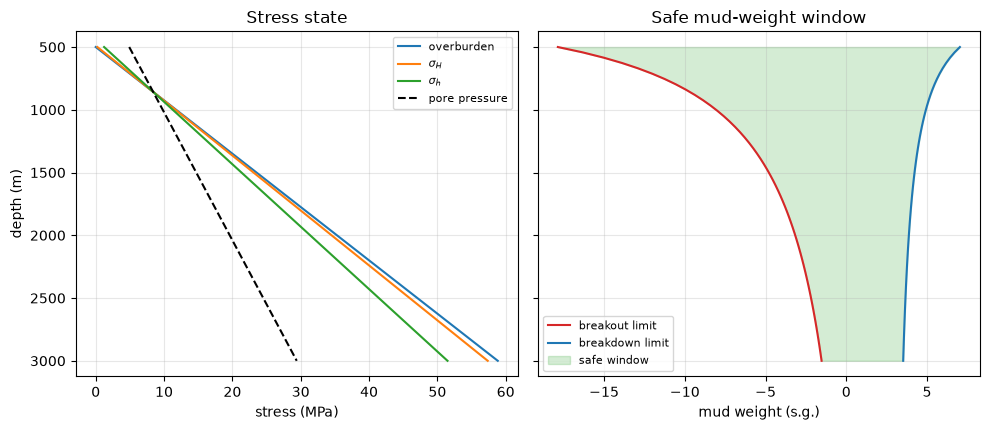

at 500 m:  brittleness 0.45   closure stress 3 MPa
UCS from the DYNAMIC modulus  :    360 MPa  (upper bound)
UCS after a 2x static correction:    109 MPa
-> the correlation is quadratic in E, so the dynamic/static choice moves
   UCS by far more than a factor of two. Calibrate against core if you can.


In [5]:
depth = np.linspace(500.0, 3000.0, 60)
density = np.full_like(depth, 2400.0)
vs_d = 2300.0 - 0.0  # constant formation for a clean illustration
moduli = elastic_moduli(vp=np.full_like(depth, 4000.0),
                        vs=np.full_like(depth, vs_d),
                        rho=density)

sigma_v = overburden_stress(depth, density)
pore = hydrostatic_pressure(depth)
geo = geomechanics_indices(moduli, sigma_v_pa=sigma_v, pore_pressure_pa=pore)
ucs = unconfined_compressive_strength(moduli.young)
# Dynamic-to-static: a factor of ~2 is a common rule of thumb for porous rock.
ucs_static = unconfined_compressive_strength(moduli.young / 2.0)

# A mildly anisotropic horizontal stress state.
sigma_h = 0.75 * (sigma_v - pore) + pore
sigma_H = 0.95 * (sigma_v - pore) + pore
window = safe_mud_weight_window(
    sigma_H=sigma_H, sigma_h=sigma_h, pore_pressure=pore, ucs=ucs,
    tensile_strength=0.1 * ucs,
)

g = 9.80665
to_sg = lambda p: p / (depth * g * 1000.0)  # Pa -> specific gravity

fig, axes = plt.subplots(1, 2, figsize=(10, 4.4), sharey=True)
axes[0].plot(sigma_v / 1e6, depth, label="overburden")
axes[0].plot(sigma_H / 1e6, depth, label=r"$\sigma_H$")
axes[0].plot(sigma_h / 1e6, depth, label=r"$\sigma_h$")
axes[0].plot(pore / 1e6, depth, "k--", label="pore pressure")
axes[0].set_xlabel("stress (MPa)"); axes[0].set_ylabel("depth (m)")
axes[0].set_title("Stress state"); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

axes[1].plot(to_sg(window.breakout_pressure), depth, color="tab:red", label="breakout limit")
axes[1].plot(to_sg(window.breakdown_pressure), depth, color="tab:blue", label="breakdown limit")
axes[1].fill_betweenx(depth, to_sg(window.breakout_pressure), to_sg(window.breakdown_pressure),
                      color="tab:green", alpha=0.2, label="safe window")
axes[1].set_xlabel("mud weight (s.g.)"); axes[1].set_title("Safe mud-weight window")
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
axes[0].invert_yaxis()
plt.tight_layout()
plt.show()

print(f"at {depth[0]:.0f} m:  brittleness {float(geo.brittleness[0]):.2f}   "
      f"closure stress {float(geo.closure_stress[0]) / 1e6:.0f} MPa")
print(f"UCS from the DYNAMIC modulus  : {float(ucs[0]) / 1e6:6.0f} MPa  (upper bound)")
print(f"UCS after a 2x static correction: {float(ucs_static[0]) / 1e6:6.0f} MPa")
print("-> the correlation is quadratic in E, so the dynamic/static choice moves")
print("   UCS by far more than a factor of two. Calibrate against core if you can.")

## What we did

Slowness logs went in; moduli, a fluid-substituted reservoir case, a
permeability curve and a drillable mud-weight window came out. That is the
`fwap` extension layer doing the job the 1994 workflows set up.

Caveats worth carrying:

* **Dispersion is not optional.** The flexural bias shown in section 1 is tens
  of µs/ft at high frequency — larger than most of the effects downstream.
* **Gassmann assumes** a homogeneous, isotropic, well-connected frame at low
  frequency. It is a good first answer and a poor last one.
* **Rock strength is the weakest link.** The UCS correlation is quadratic in
  Young's modulus and was fitted on static core moduli, so feeding it a dynamic
  sonic modulus inflates the answer badly — as the two printed values show.
* The stress state in section 4 is *assumed*, not measured. A real study
  calibrates the horizontal-stress ratio against leak-off tests and breakout
  logs; the pipeline is only as good as those inputs.

Next: the [`sonic_ml` tutorial](sonic_ml_tutorial.ipynb) treats the same forward
physics as training data for a learned inverse, and the
[cased-hole tutorial](cased_hole_tutorial.ipynb) takes the whole chain behind
casing.